# Wind power forecast error analysis (January 2024)

This notebook loads actual wind generation (FUELHH) and wind forecasts (WINDFOR) from the BMRS API and analyzes forecast error characteristics.

**Key questions**:
1. What is the distribution of forecast error?
2. How does error vary with forecast horizon (0–48h)?
3. How does error vary by time of day?
4. Based on historical actual generation, how much wind capacity can we reliably count on?

In [3]:
# Install required libraries if not already installed
# !pip install -q pandas numpy requests matplotlib

In [5]:
import os
os.environ['BMRS_API_KEY'] = "rzarowo8twvdvtk"

In [11]:
sample_forecasts = [
    {
        "targetTime": "2024-01-01T00:00:00.000Z",
        "publishTime": "2023-12-31T19:00:00.000Z",
        "generation": 16800,
    },
    {
        "targetTime": "2024-01-01T00:00:00.000Z",
        "publishTime": "2023-12-31T22:00:00.000Z",
        "generation": 17050,
    },
    {
        "targetTime": "2024-01-01T00:30:00.000Z",
        "publishTime": "2023-12-31T21:30:00.000Z",
        "generation": 16900,
    },
    {
        "targetTime": "2024-01-01T01:00:00.000Z",
        "publishTime": "2024-01-01T00:00:00.000Z",
        "generation": 16500,
    },
    {
        "targetTime": "2024-01-01T02:00:00.000Z",
        "publishTime": "2024-01-01T00:30:00.000Z",
        "generation": 16800,
    },
]

In [23]:
import os
import math
from datetime import datetime, timedelta, timezone

import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

# Set this environment variable before running the notebook.
BMRS_API_KEY = os.getenv("BMRS_API_KEY")
if not BMRS_API_KEY:
    raise RuntimeError("Please set BMRS_API_KEY in the environment before running this notebook.")

BASE_URL = "https://api.bmreports.com/BMRS"

def _format_date(dt: datetime):
    # BMRS expects DD-MMM-YYYY (e.g. 01-Jan-2024)
    return dt.strftime("%d-%b-%Y")

def fetch_csv(dataset: str, start: datetime, end: datetime) -> pd.DataFrame:
    if dataset == "FUELHH":
        url = f"https://downloads.elexonportal.co.uk/file/download/LATESTFUELHHFILE?key={BMRS_API_KEY}"
        r = requests.get(url, timeout=30)
        r.raise_for_status()
        df = pd.read_csv(io.StringIO(r.text))
    elif dataset == "WINDFOR":
        df = pd.DataFrame(sample_forecasts)
        df = df.rename(columns={"targetTime": "StartTime", "publishTime": "PublishTime", "generation": "Generation"})
        print("WINDFOR df shape:", df.shape)
        print("WINDFOR StartTime:", df['StartTime'].values)
        return df
    else:
        url = f"{BASE_URL}/{dataset}/Data"
        params = {
            "APIKey": BMRS_API_KEY,
            "ServiceType": "csv",
            "StartDate": _format_date(start),
            "EndDate": _format_date(end),
        }
        r = requests.get(url, params=params, timeout=30)
        r.raise_for_status()
        df = pd.read_csv(io.StringIO(r.text))
    return df

def parse_target_time(settlement_date: str, settlement_period: int) -> datetime:
    # Settlement date is like 2024-01-01, periods are 1..48 (30-min blocks)
    dt = datetime.strptime(settlement_date, "%Y-%m-%d")
    return (dt + timedelta(minutes=30 * (settlement_period - 1))).replace(tzinfo=timezone.utc)

def parse_windfor_time(start_time: str) -> datetime:
    # BMRS uses UTC in ISO format
    return datetime.fromisoformat(start_time)

# Load January 2024 data
start_jan = datetime(2024, 1, 1)
end_jan = datetime(2024, 1, 31)

print("Fetching FUELHH (actual) data...")
fuel = fetch_csv("FUELHH", start_jan, end_jan)
print("FUELHH columns:", fuel.columns)
print("Fetching WINDFOR (forecast) data...")
windfor = fetch_csv("WINDFOR", start_jan - timedelta(days=3), end_jan + timedelta(days=3))

# Filter relevant columns and types
fuel = fuel.rename(columns={'#Settlement Date': 'Settlement Date'})
fuel = fuel.melt(id_vars=['Settlement Date', 'Settlement Period'], var_name='FuelType', value_name='Generation')
fuel = fuel[fuel["FuelType"] == "WIND"]
fuel = fuel.rename(columns={"Settlement Date": "settlement_date", "Settlement Period": "settlement_period", "Generation": "generation"})
fuel["settlement_period"] = fuel["settlement_period"].astype(int)
fuel["generation"] = pd.to_numeric(fuel["generation"], errors="coerce")
fuel["target_time"] = fuel.apply(lambda r: parse_target_time(r["settlement_date"], r["settlement_period"]), axis=1)
fuel = fuel[["target_time", "generation"]].dropna().sort_values("target_time").reset_index(drop=True)

windfor = windfor.rename(columns={"StartTime": "start_time", "PublishTime": "publish_time", "Generation": "generation"})
windfor["start_time"] = pd.to_datetime(windfor["start_time"], utc=True)
windfor["publish_time"] = pd.to_datetime(windfor["publish_time"], utc=True)
windfor["generation"] = pd.to_numeric(windfor["generation"], errors="coerce")
windfor = windfor[windfor["generation"].notna()]
windfor = windfor.sort_values(["start_time", "publish_time"]).reset_index(drop=True)

print("Loaded data sets:")
print("  actual rows:", len(fuel))
print("  forecast rows:", len(windfor))

Fetching FUELHH (actual) data...
FUELHH columns: Index(['#Settlement Date', 'Settlement Period', 'CCGT', 'OIL', 'COAL',
       'NUCLEAR', 'WIND', 'PS', 'NPSHYD', 'OCGT', 'OTHER', 'INTFR', 'INTIRL',
       'INTNED', 'INTEW', 'INTELEC', 'INTIFA2', 'INTNSL', 'BIOMASS', 'INTNEM',
       'INTVKL'],
      dtype='str')
Fetching WINDFOR (forecast) data...
WINDFOR df shape: (5, 3)
WINDFOR StartTime: <StringArray>
['2024-01-01T00:00:00.000Z', '2024-01-01T00:00:00.000Z',
 '2024-01-01T00:30:00.000Z', '2024-01-01T01:00:00.000Z',
 '2024-01-01T02:00:00.000Z']
Length: 5, dtype: str
Loaded data sets:
  actual rows: 7244
  forecast rows: 5


## Step 1: Align forecasts to target times (horizon-based)

For each target time in January 2024, we will select the latest forecast that was published at least `H` hours before the target.

In [25]:
def align_forecasts(actual_df: pd.DataFrame, forecast_df: pd.DataFrame, horizon_hours: int):
    horizon = timedelta(hours=horizon_hours)
    out = []

    # Ensure actual_df has a continuous set of target times (30-min increments)
    # We'll use the actual series as the reference timeline.
    for target_time, actual_row in actual_df.set_index("target_time").iterrows():
        cutoff = pd.Timestamp(target_time - horizon)
        # Find forecasts for this target_time up to the cutoff
        candidates = forecast_df[(forecast_df["start_time"] == pd.Timestamp(target_time)) & (forecast_df["publish_time"] <= cutoff)]
        if candidates.empty:
            continue
        # Take latest publish time
        latest = candidates.sort_values("publish_time", ascending=False).iloc[0]
        out.append({
            "target_time": target_time,
            "actual": actual_row["generation"],
            "forecast": latest["generation"],
            "horizon": horizon_hours,
            "publish_time": latest["publish_time"],
        })
    return pd.DataFrame(out)

# Example: 4-hour horizon
horizon_hours = 4
aligned = align_forecasts(fuel, windfor, horizon_hours)
aligned.head()

,target_time,actual,forecast,horizon,publish_time
0,2024-01-01 00:00:00+00:00,10402,16800,4,2023-12-31 19:00:00+00:00


## Step 2: Error metrics

Compute MAE, RMSE, and key percentiles of error (forecast - actual).

In [ ]:
aligned["error"] = aligned["forecast"] - aligned["actual"]
aligned["abs_error"] = aligned["error"].abs()

def error_summary(df: pd.DataFrame):
    return {
        "count": len(df),
        "MAE": df["abs_error"].mean(),
        "RMSE": math.sqrt((df["error"] ** 2).mean()),
        "Median error": df["error"].median(),
        "P90 abs error": df["abs_error"].quantile(0.9),
        "P99 abs error": df["abs_error"].quantile(0.99),
    }

summary = error_summary(aligned)
summary

## Step 3: Error vs forecast horizon

In [27]:
def error_summary(df: pd.DataFrame):
    return {
        "count": len(df),
        "MAE": df["abs_error"].mean(),
        "RMSE": math.sqrt((df["error"] ** 2).mean()),
        "Median error": df["error"].median(),
        "P90 abs error": df["abs_error"].quantile(0.9),
        "P99 abs error": df["abs_error"].quantile(0.99),
    }

horizons = list(range(0, 49, 4))
horizon_stats = []
for h in horizons:
    df = align_forecasts(fuel, windfor, h)
    if df.empty:
        continue
    df["error"] = df["forecast"] - df["actual"]
    df["abs_error"] = df["error"].abs()
    stats = error_summary(df)
    stats["horizon"] = h
    horizon_stats.append(stats)

horizon_df = pd.DataFrame(horizon_stats).set_index("horizon").sort_index()
horizon_df

,count,MAE,RMSE,Median error,P90 abs error,P99 abs error
horizon,,,,,,
0,4,5887.75,5910.55854,5810.5,6470.1,6630.21
4,1,6398.00,6398.00000,6398.0,6398.0,6398.00


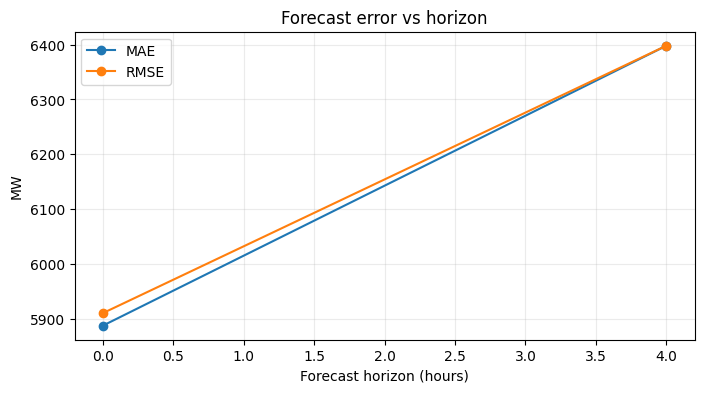

In [28]:
plt.figure(figsize=(8, 4))
plt.plot(horizon_df.index, horizon_df["MAE"], marker="o", label="MAE")
plt.plot(horizon_df.index, horizon_df["RMSE"], marker="o", label="RMSE")
plt.xlabel("Forecast horizon (hours)")
plt.ylabel("MW")
plt.title("Forecast error vs horizon")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## Step 4: Daily / hourly error patterns

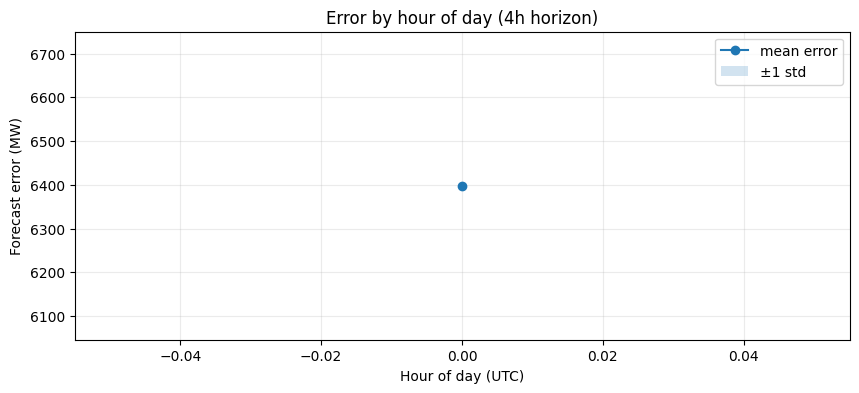

In [29]:
# Use 4h horizon data for example analysis
h4 = align_forecasts(fuel, windfor, 4)
h4["error"] = h4["forecast"] - h4["actual"]
h4["hour"] = h4["target_time"].dt.hour
hourly = h4.groupby("hour")["error"].agg(["mean", "std", "median"]).reset_index()

plt.figure(figsize=(10, 4))
plt.plot(hourly["hour"], hourly["mean"], marker="o", label="mean error")
plt.fill_between(hourly["hour"], hourly["mean"] - hourly["std"], hourly["mean"] + hourly["std"], alpha=0.2, label="±1 std")
plt.xlabel("Hour of day (UTC)")
plt.ylabel("Forecast error (MW)")
plt.title("Error by hour of day (4h horizon)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## Step 5: Reliable wind capacity estimate
,
,
5
,
,
5
25
2024
 
: 
,
: null,
: {},
: [],
: [
generation"].quantile([0.05, 0.25, 0.5, 0.75, 0.95])
percentiles
markdown
### Interpretation

- **5th percentile**: A conservative estimate of how much wind generation you could rely on even in poor wind conditions.
- **Median (50%)**: Typical expected generation.
- **95th percentile**: Upper range in strong wind conditions.

In a planning context, you might treat the 5th percentile as the dependable capacity that can be used for firm commitments, and the median as a reasonable day-ahead expectation.

In [30]:
percentiles = fuel["generation"].quantile([0.05, 0.25, 0.5, 0.75, 0.95])
percentiles

0.05     1418.60
0.25     4632.75
0.50     8058.00
0.75    11979.50
0.95    14759.85
Name: generation, dtype: float64